## Example 2a:
Example workflow that trains a CNN to predict the amplitude and phase aberration coefficients from a z-stack, using synthetic examples generated from the forwards model on-the-fly as training data.

For each batch, new phase and amplitude coefficients are randomly sampled from a set of prior distributions, and the forwards simulator is used to create the corresponding z-stacks. We now have a batch of z-stack images labeled with their true (insofar as the forwards model works) coefficients, and can train a CNN to solve the inverse problem, going from images to their aberration coefficients.

In [1]:
import logging
from pathlib import Path
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar, safe_load_from_checkpoint
from cynosure.utilities.visualization import plot_stack
from cynosure.zstack_decoding import ZstackSolver_MLE
from cynosure.zstack_decoding.posterior_heads import get_default_cnn_encoder_spec

 #### Simulation setup

In [4]:
use_pretrained = True  # enable to load weights from one of my checkpoints

train_cfg = get_default_training_config(generator_chunk=16)
sim_cfg = get_default_simulation_config(object_pixel_size=0.1)
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config(
    allowed_nm=(
        (0, 0),
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -1), (3, 1),
        (4, 0),
    )
)
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()
encoder_spec = get_default_cnn_encoder_spec()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
rng_seed = 123
dz = 0.2  # um, physical objective z-step
num_z = 7  # number of z-slices to fit, ~centered around the focal plane
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
z = torch.arange(-(num_z//2), num_z//2 + 1).float() * dz

#### Solver setup and training

In [7]:
_ = pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MLE(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    z_objective=z,
    object_distribution=object_distrib,
    noise_cfg=noise_cfg,
    encoder_spec=encoder_spec,
)
solver = solver.to(device)

Seed set to 123


In [8]:
checkpoint_path = Path("./pretrained_models/example_2a/checkpoints/final.ckpt")
if use_pretrained:
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=5,
        accelerator=device,
        log_every_n_steps=50,
        callbacks=[NoValidationBar()],
    )
    trainer.fit(solver)
    solver = solver.eval()

#### Sanity checking the results

Generate another set of synthetic examples (images + aberrations), then use the fitted model to predict the aberrations anew from the images alone.
Forwards-propagating the predicted coefficients produces the predicted images, which should match the ground truth images well.
This doesn't establish correctness, but it at least shows self-consistency.

In [9]:
_ = pl.seed_everything(rng_seed+1, workers=True)

Seed set to 124


In [10]:
batch_size = 4
with torch.inference_mode():
    images, _, phase_coefs, amp_coefs = solver.simulator.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)
    pred_images = solver.simulator.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

Arbitrarily choose the `batch_index=0` element to compare.

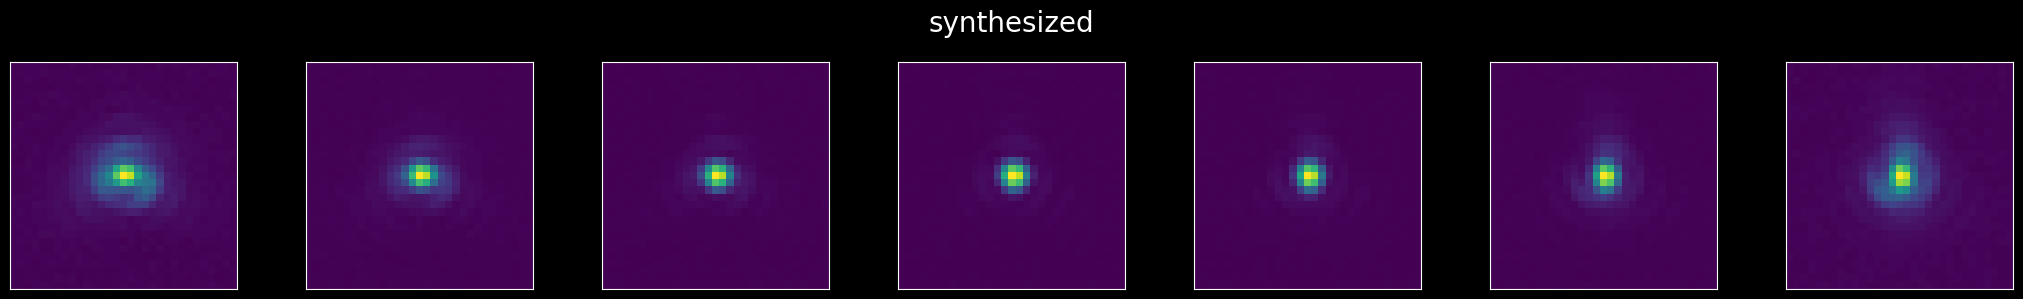

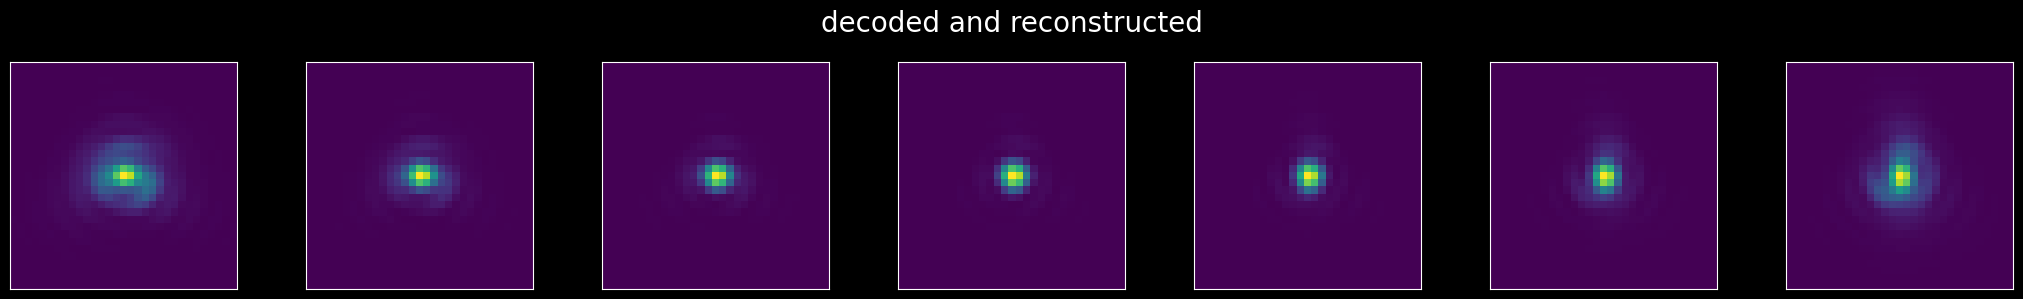

In [11]:
bidx = 0

fig1 = plot_stack(images.numpy(force=True)[bidx])
fig1.suptitle("synthesized", size=20)
fig1.tight_layout()

fig2 = plot_stack(pred_images.numpy(force=True)[bidx])
fig2.suptitle("decoded and reconstructed", size=20)
fig2.tight_layout()